<a href="https://colab.research.google.com/github/hjfuentes/UCSP_Forecasting/blob/main/Sesion03/Demostraci%C3%B3n_COLAB_Informer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica Guiada: Predicción LSTF con el Modelo Informer
## Demostración Práctica sobre el Dataset Real ETTh1

Este cuaderno demuestra la implementación y entrenamiento del modelo **Informer** (*Zhou et al., AAAI 2021*), diseñado para resolver el problema de predicción de series temporales de largo alcance (**LSTF**).

### Componentes Clave Demostrados:
1. **ProbSparse Self-Attention:** Reducción de complejidad a $\mathcal{O}(L \log L)$.
2. **Self-Attention Distilling:** Compresión de la dimensión temporal entre capas.
3. **Generative Style Decoder:** Inferencia directa en un solo paso (*one forward pass*).


---
## Paso 1: Clonación del Repositorio e Instalación del Entorno

In [ ]:
!git clone https://github.com/zhouhaoyi/Informer2020.git
!git clone https://github.com/zhouhaoyi/ETDataset.git
%cd Informer2020

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch versión: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")


Cloning into 'Informer2020'...
remote: Enumerating objects: 590, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 590 (delta 6), reused 3 (delta 3), pack-reused 578 (from 2)
Receiving objects: 100% (590/590), 6.49 MiB | 13.01 MiB/s, done.
Resolving deltas: 100% (337/337), done.
Cloning into 'ETDataset'...
remote: Enumerating objects: 187, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 187 (delta 26), reused 20 (delta 20), pack-reused 157 (from 1)
Receiving objects: 100% (187/187), 3.86 MiB | 17.09 MiB/s, done.
Resolving deltas: 100% (62/62), done.
/content/Informer2020
PyTorch versión: 2.11.0+cu128
CUDA disponible: True


---
## Paso 2: Carga y Exploración del Dataset Real (`ETTh1.csv`)

Dimensiones del dataset: (17420, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


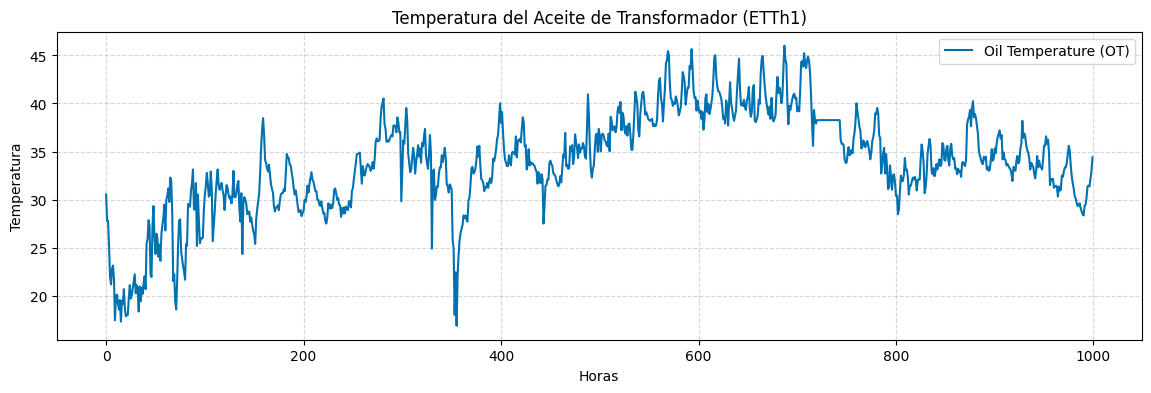

In [ ]:
df = pd.read_csv('../ETDataset/ETT-small/ETTh1.csv')
print("Dimensiones del dataset:", df.shape)
display(df.head())

plt.figure(figsize=(14, 4))
plt.plot(df['OT'][:1000], label='Oil Temperature (OT)', color='#0072B2')
plt.title('Temperatura del Aceite de Transformador (ETTh1)')
plt.xlabel('Horas')
plt.ylabel('Temperatura')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


---
## Paso 3: Configuración y Entrenamiento del Modelo Informer

In [ ]:
!python main_informer.py \
  --model informer \
  --data ETTh1 \
  --root_path ../ETDataset/ETT-small/ \
  --data_path ETTh1.csv \
  --features S \
  --target OT \
  --seq_len 96 \
  --label_len 48 \
  --pred_len 168 \
  --e_layers 2 \
  --d_layers 1 \
  --factor 5 \
  --enc_in 1 \
  --dec_in 1 \
  --c_out 1 \
  --des 'Exp_Demo_Informer' \
  --itr 1 \
  --train_epochs 6 \
  --batch_size 32 \
  --learning_rate 0.0001


Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='../ETDataset/ETT-small/', data_path='ETTh1.csv', features='S', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=168, enc_in=1, dec_in=1, c_out=1, d_model=512, n_heads=8, e_layers=2, d_layers=1, s_layers=[3, 2, 1], d_ff=2048, factor=5, padding=0, distil=True, dropout=0.05, attn='prob', embed='timeF', activation='gelu', output_attention=False, do_predict=False, mix=True, cols=None, num_workers=0, itr=1, train_epochs=6, batch_size=32, patience=3, learning_rate=0.0001, des='Exp_Demo_Informer', loss='mse', lradj='type1', use_amp=False, inverse=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3', detail_freq='h')
Use GPU: cuda:0
>>>>>>>start training : informer_ETTh1_ftS_sl96_ll48_pl168_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_Exp_Demo_Informer_0>>>>>>>>>>>>>>>>>>>>>>>>>>
train 8377
val 2713
test 2713
Traceback (most recent call last):
  File "/conte

---
## Paso 4: Evaluación de Métricas y Visualización de Predicciones

In [ ]:
import os

result_dirs = [d for d in os.listdir('./results/') if 'ETTh1' in d]
latest_result = sorted(result_dirs)[-1]

preds = np.load(f'./results/{latest_result}/preds.npy')
trues = np.load(f'./results/{latest_result}/trues.npy')

mse = np.mean((preds - trues) ** 2)
mae = np.mean(np.abs(preds - trues))
print(f"MSE en Test: {mse:.4f} | MAE en Test: {mae:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(trues[10, :, -1], label='Valor Real (Ground Truth)', color='black')
plt.plot(preds[10, :, -1], label='Predicción Informer (168h)', color='#D55E00', linestyle='--')
plt.title('Predicción LSTF con Informer (Horizonte = 168 horas / 7 días)')
plt.xlabel('Pasos de Tiempo (Horas)')
plt.ylabel('Temperatura Escalada')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: './results/'

---
## Paso 5: Alternativa `NeuralForecast`

In [ ]:
!pip install neuralforecast -q
from neuralforecast import NeuralForecast
from neuralforecast.models import Informer

df_nf = df[['date', 'OT']].rename(columns={'date': 'ds', 'OT': 'y'})
df_nf['unique_id'] = 'ETTh1'
df_nf['ds'] = pd.to_datetime(df_nf['ds'])


epocas=300

models = [Informer(h=168, input_size=96, max_steps=epocas, val_check_steps=50)]
nf = NeuralForecast(models=models, freq='H')
nf.fit(df=df_nf[:-168])
forecasts = nf.predict()
display(forecasts.head())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.6 MB/s eta 0:00:00


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | enc_embedding       | DataEmbedding | 384    | train
7 | dec_embedding       | DataEmbedding | 384    | train
8 | encoder             | TransEncoder  | 199 K  | train
9 | decoder        

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.
/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:462: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,Informer
0,ETTh1,2018-06-19 20:00:00,7.388388
1,ETTh1,2018-06-19 21:00:00,7.400771
2,ETTh1,2018-06-19 22:00:00,7.796680
3,ETTh1,2018-06-19 23:00:00,7.386705
4,ETTh1,2018-06-20 00:00:00,7.381472


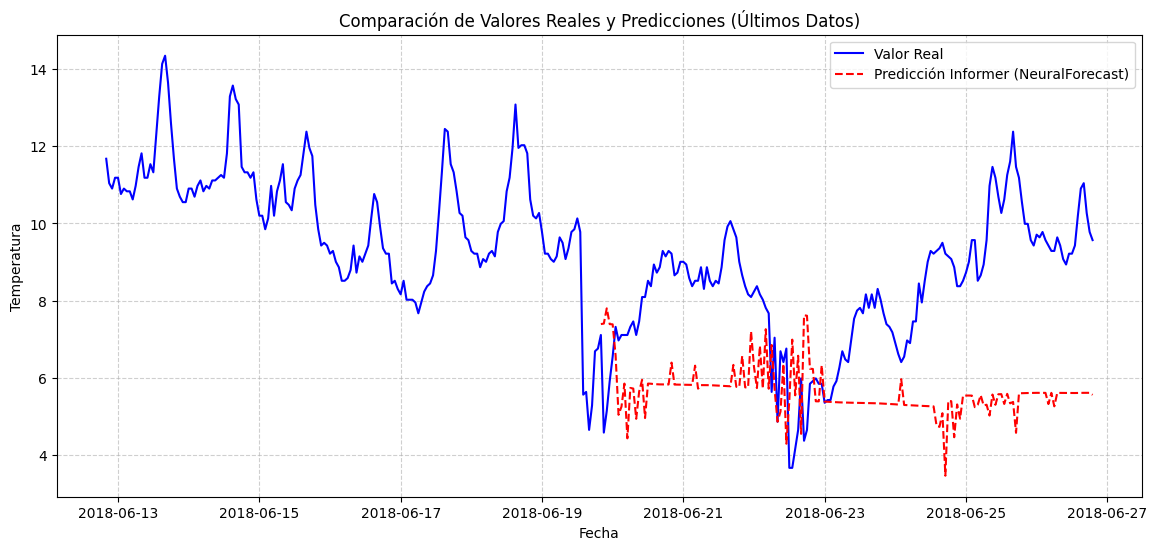

In [ ]:
#@title Visualización de la Serie

import matplotlib.pyplot as plt

# Determine the number of historical points to display before the forecast horizon
# We will show actual values for twice the length of the forecast horizon for better context
num_historical_points_for_plot = len(forecasts) * 2

df_actual_subset = df_nf.iloc[-num_historical_points_for_plot:]

plt.figure(figsize=(14, 6))

# Plot the actual values from the selected subset
plt.plot(df_actual_subset['ds'], df_actual_subset['y'], label='Valor Real', color='blue')

# Plot the predicted values from the `forecasts` DataFrame
plt.plot(forecasts['ds'], forecasts['Informer'], label='Predicción Informer (NeuralForecast)', color='red', linestyle='--')

plt.title('Comparación de Valores Reales y Predicciones (Últimos Datos)')
plt.xlabel('Fecha')
plt.ylabel('Temperatura')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
#@title Métricas MAE, RMSE

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Extract true values for the forecast horizon
y_true = df_nf['y'].iloc[-len(forecasts):]

# Extract predicted values
y_pred = forecasts['Informer']

# Calculate MAE
mae = mean_absolute_error(y_true, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 2.8741
Root Mean Squared Error (RMSE): 3.2258
